This is a EDA file for the housing data


# Importing Libraries and Setup


In [26]:
import pandas as pd
import sys
from pathlib import Path, __file__
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

In [4]:
current_dir = Path.cwd().parent
sys.path.append(str(current_dir))
from src.config import RAW_DATA_DIR, HOUSING_DATA

## Load the data


In [5]:
housing_raw = pd.read_csv(HOUSING_DATA)
housing_raw.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# EDA - 1


## shape


In [6]:
housing_raw.shape

(20640, 10)

## Columns


In [7]:
housing_raw.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

## info


In [8]:
housing_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Ocean Proximity Categories


In [9]:
housing_raw["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## Summary


In [10]:
housing_raw.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Histogram


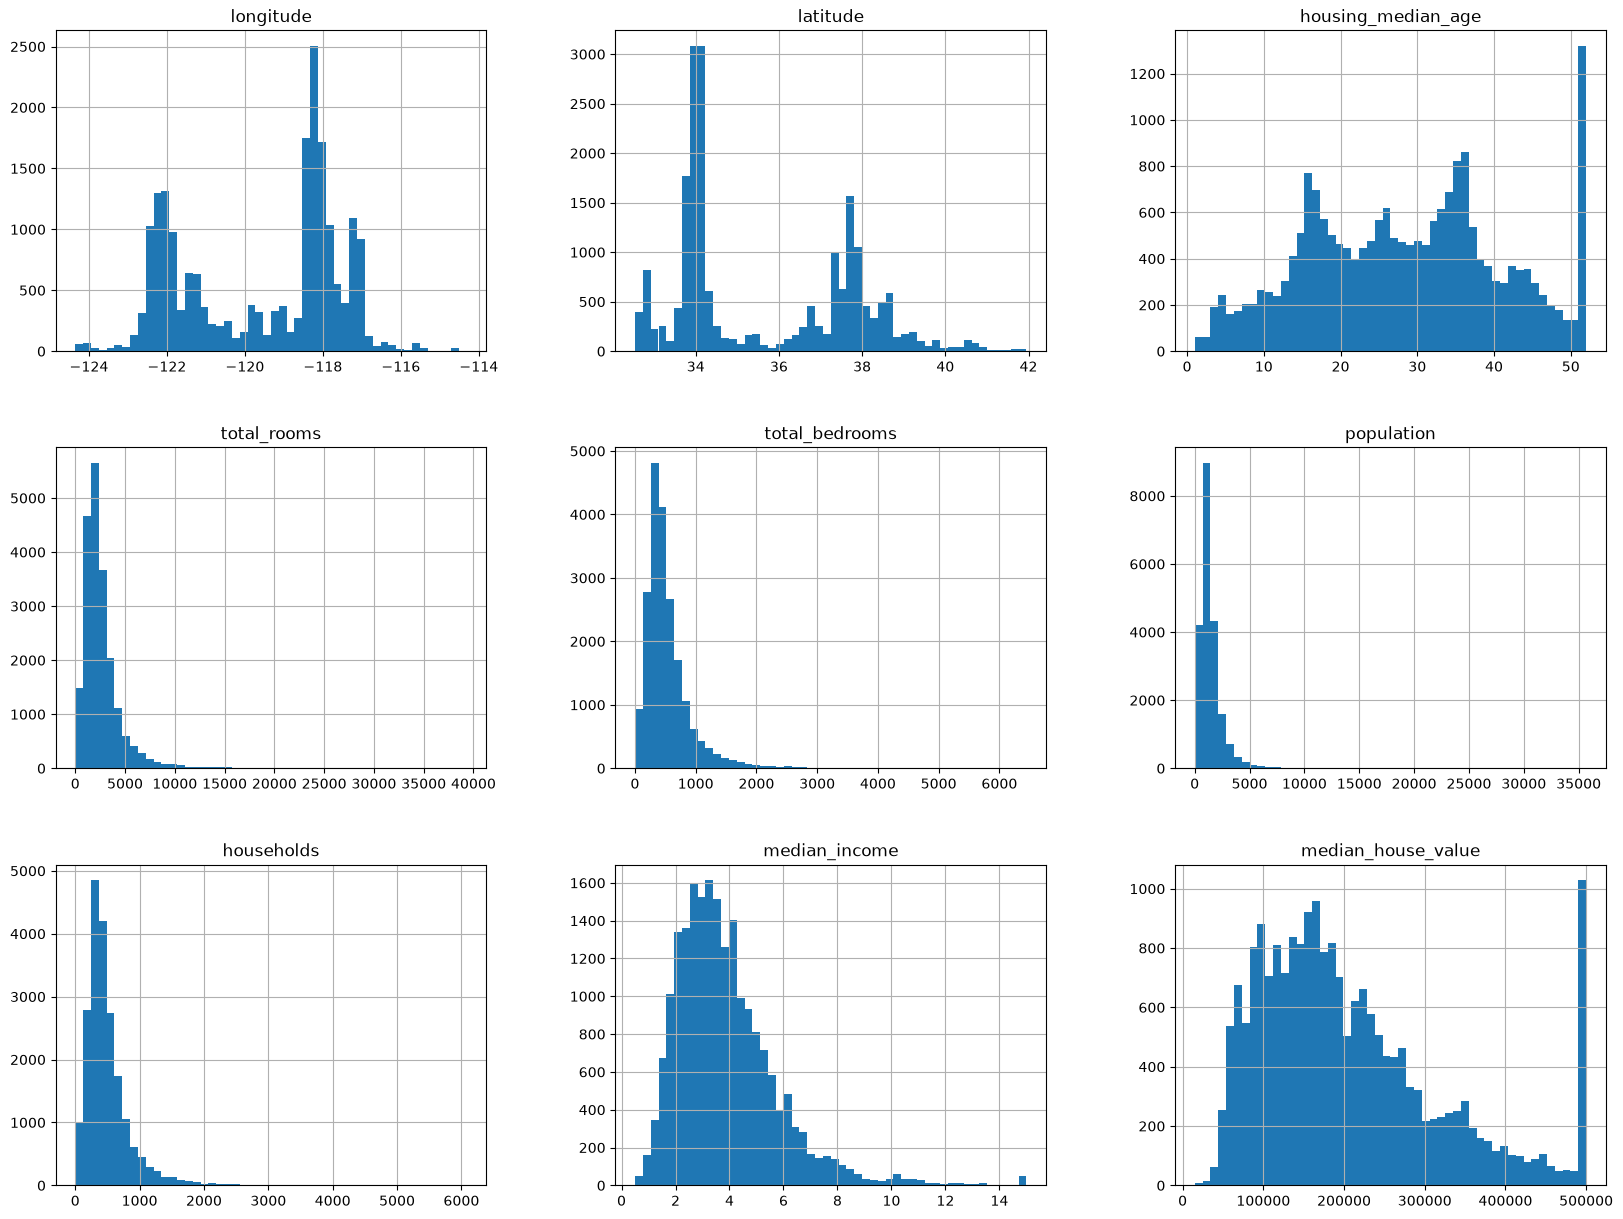

In [11]:
housing_raw.hist(bins=50, figsize=(20, 15))
plt.show()

## Median income Histogram


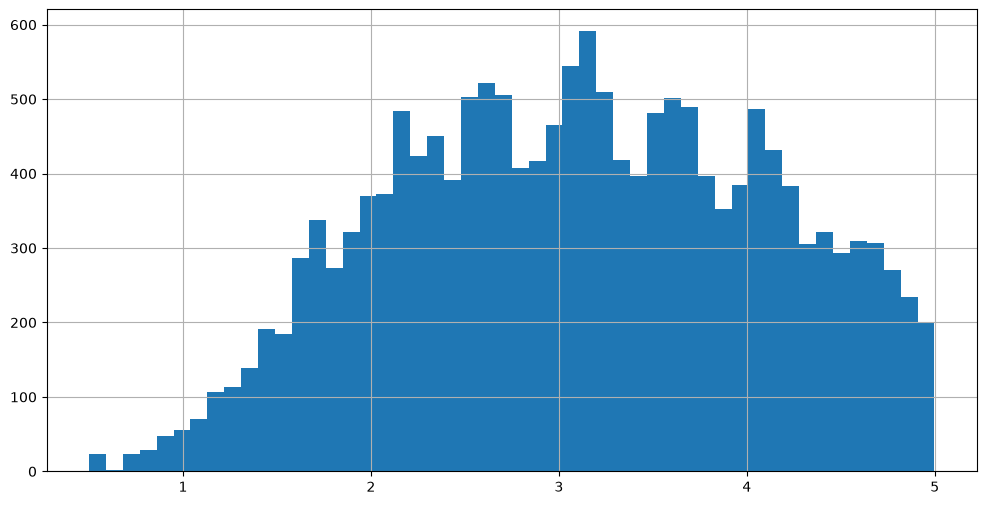

In [12]:
housing_raw[housing_raw["median_income"] < 5]["median_income"].hist(
    bins=50, figsize=(12, 6)
)
plt.show()

# Train - Test split


In [35]:
train_size = int(len(housing_raw) * 0.8)
train = housing_raw[:train_size]
test = housing_raw[train_size:]

In [36]:
train["income_cat"].value_counts() / len(train)

income_cat
3.0    0.355499
2.0    0.328791
4.0    0.165092
5.0    0.107558
1.0    0.043060
Name: count, dtype: float64

In [37]:
test["income_cat"].value_counts() / len(test)

income_cat
3.0    0.330911
2.0    0.279070
4.0    0.221172
5.0    0.141957
1.0    0.026890
Name: count, dtype: float64

## Manual method


In [13]:
# def split_train_test(data, test_ratio=0.2):
#     np.random.seed(42)
#     shuffled_indices = np.random.permutation(len(data))
#     test_set_size = int(len(data) * test_ratio)
#     test_indices = shuffled_indices[:test_set_size]
#     train_indices = shuffled_indices[test_set_size:]
#     return data.iloc[train_indices], data.iloc[test_indices]

In [14]:
# train_data, test_data = split_train_test(housing_raw, 0.2)

In [15]:
# print(f"Shape of the training data; {train_data.shape}")
# print(f"Shape of the test data; {test_data.shape}")

## Using scikitlearn


In [34]:
train_data, test_data = train_test_split(housing_raw, test_size=0.2, random_state=42)

In [ ]:
# print(f"Shape of the training data; {train_data.shape}")
# print(f"Shape of the test data; {test_data.shape}")

Shape of the training data; (16512, 10)
Shape of the test data; (4128, 10)


In [38]:
train_data["income_cat"].value_counts() / len(train_data)

income_cat
3.0    0.348595
2.0    0.317466
4.0    0.178537
5.0    0.115673
1.0    0.039729
Name: count, dtype: float64

In [39]:
test_data["income_cat"].value_counts() / len(test_data)

income_cat
3.0    0.358527
2.0    0.324370
4.0    0.167393
5.0    0.109496
1.0    0.040213
Name: count, dtype: float64

## Stratified sampling


In [22]:
housing_raw["income_cat"] = np.ceil(housing_raw["median_income"] / 1.5)
housing_raw[["median_income", "income_cat"]]

,median_income,income_cat
0,8.3252,6.0
1,8.3014,6.0
2,7.2574,5.0
3,5.6431,4.0
4,3.8462,3.0
...,...,...
20635,1.5603,2.0
20636,2.5568,2.0
20637,1.7000,2.0
20638,1.8672,2.0


In [ ]:
housing_raw["income_cat"].unique()

array([ 6.,  5.,  4.,  3.,  2.,  1.,  8.,  7.,  9., 11., 10.])

In [25]:
housing_raw["income_cat"] = housing_raw["income_cat"].where(
    housing_raw["income_cat"] < 5, 5.0
)
housing_raw[["median_income", "income_cat"]]

,median_income,income_cat
0,8.3252,5.0
1,8.3014,5.0
2,7.2574,5.0
3,5.6431,4.0
4,3.8462,3.0
...,...,...
20635,1.5603,2.0
20636,2.5568,2.0
20637,1.7000,2.0
20638,1.8672,2.0


In [27]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [28]:
split

StratifiedShuffleSplit(n_splits=1, random_state=42, test_size=0.2,
            train_size=None)

In [ ]:
for train_index, test_index in split.split(housing_raw, housing_raw["income_cat"]):
    strat_train_set = housing_raw.iloc[train_index]
    strat_test_set = housing_raw.iloc[test_index]

In [31]:
housing_raw["income_cat"].value_counts() / len(housing_raw)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [ ]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

In [33]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)

income_cat
3.0    0.350594
2.0    0.318859
4.0    0.176296
5.0    0.114462
1.0    0.039789
Name: count, dtype: float64

## Remove income cat


In [40]:
for set in (strat_train_set, strat_test_set):
    set.drop(["income_cat"], axis=1, inplace=True)

# EDA - 2


In [41]:
# copy of the training set  to play with
housing_train = strat_train_set.copy()

## histogram - geography


<Axes: xlabel='longitude', ylabel='latitude'>

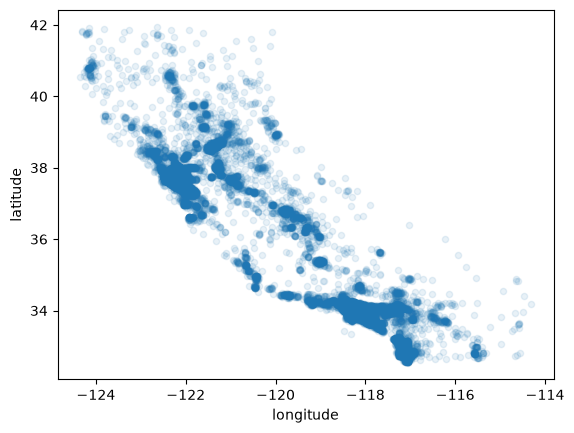

In [43]:
housing_train.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

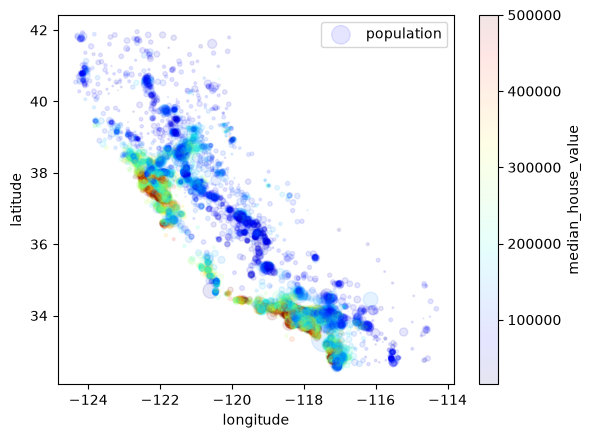

In [44]:
housing_train.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.1,
    s=housing_train["population"] / 100,  # The s stands for size.
    label="population",
    c="median_house_value",  # The c stands for color.
    cmap=plt.get_cmap(
        "jet"
    ),  # blue (cheap houses) to green/yellow (mid-range) to red (expensive houses)
    colorbar=True,
)
plt.legend()

## Correlation coefficent


In [46]:
corr_matrix = housing_train.corr(numeric_only=True)

In [47]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

## Histogram - income-price


<Axes: xlabel='median_income', ylabel='median_house_value'>

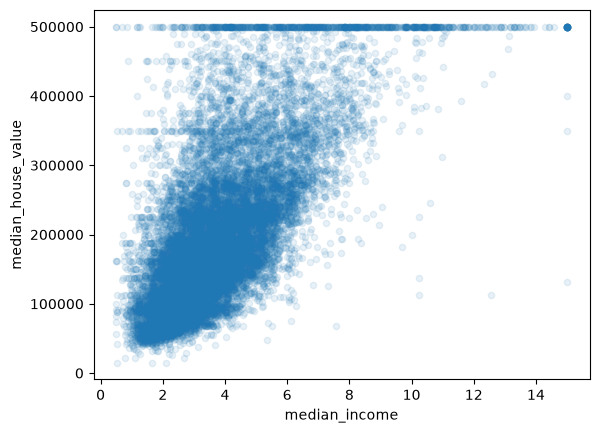

In [49]:
housing_train.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

## Feature Extraction


In [50]:
housing_train["rooms_per_household"] = (
    housing_train["total_rooms"] / housing_train["households"]
)
housing_train["bedrooms_per_rooms"] = (
    housing_train["total_bedrooms"] / housing_train["total_rooms"]
)
housing_train["population_per_household"] = (
    housing_train["population"] / housing_train["households"]
)

In [53]:
corr_matrix = housing_train.corr(numeric_only=True)

In [56]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_rooms         -0.259952
Name: median_house_value, dtype: float64